# CLASSIFYING SPAM EMAILS — BALANCED DATASET

## Project Overview

Bài toán: Phân loại email thành hai nhóm:

- Spam Email
- Non-Spam Email

Mục tiêu của notebook:

- Cân bằng tập dữ liệu bằng cách bổ sung thêm email spam từ nguồn dữ liệu ngoài.
- Khám phá dữ liệu email.
- Làm sạch và tiền xử lý văn bản.
- Phân tích các đặc trưng của email spam.
- Trích xuất đặc trưng bằng TF-IDF.
- Chuẩn bị dữ liệu cho các mô hình Machine Learning.

---

## Input

Dataset đầu vào:

| Feature | Description |
|----------|------------|
| text | Nội dung email |
| spam | Nhãn email (1 = spam, 0 = ham) |

---

## Output

Sau khi xử lý, notebook tạo ra:

### Processed Dataset

- Văn bản đã được làm sạch.
- Loại bỏ URL, số và ký tự đặc biệt.
- Chuẩn hóa chữ thường.

### Engineered Features

- Email Length
- Word Frequency
- Vocabulary Statistics
- TF-IDF Features

### Training Data

- X_train_balance
- X_test_balance
- y_train_balance
- y_test_balance

Sẵn sàng cho việc huấn luyện mô hình phân loại spam.

---

## Project Workflow

```text
Phase 1: Data Understanding
    ↓
Phase 2: Data Quality Assessment
    ↓
Phase 3: Exploratory Data Analysis
    ↓
Phase 4: Text Preprocessing
    ↓
Phase 5: Dataset Preparation
    ↓
Phase 6: Feature Engineering
```
---

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
import nltk
from nltk.stem import WordNetLemmatizer
try:
    nltk.data.find("corpora/wordnet")
except LookupError:
    nltk.download("wordnet", quiet=True)
lemmatizer = WordNetLemmatizer()
import joblib
from sklearn.model_selection import train_test_split
from collections import Counter

In [2]:
# ==================================================
# HELPER FUNCTIONS
# ==================================================

def print_section(title, width=70):
    print("\n" + "=" * width)
    print(title.center(width))
    print("=" * width)

## [Phase 1: Data Understanding]

Mục tiêu: tìm hiểu tổng quan về tập dữ liệu email trước khi tiến hành phân tích và tiền xử lý.

### 1. Load Dataset

Đọc dữ liệu email từ file `emails_raw.csv` và bổ sung email spam từ `email_raw1.csv` để cân bằng tập dữ liệu.

In [3]:
# Load cả hai file
df_raw = pd.read_csv("emails_raw.csv")
df_extra = pd.read_csv("email_raw1.csv")

# Cột trong email_raw1.csv là label => đổi tên cho giống
df_extra = df_extra.rename(columns={"label": "spam"})

# Lấy chỉ các email spam từ file bổ sung
spam_extra = df_extra[df_extra["spam"] == 1]

# Chọn 2700 email spam
spam_sample = spam_extra.sample(n=2700, random_state=42)

# Gộp với dữ liệu gốc
df = pd.concat([df_raw, spam_sample], ignore_index=True)

# Xóa trùng text sau khi gộp
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

# Lưu file mới
df.to_csv("emails_balanced.csv", index=False)

### 2. Dataset Overview

Các bước thực hiện:

- Hiển thị các dòng đầu tiên.
- Kiểm tra số lượng mẫu và thuộc tính.

In [4]:
# Head
print_section("Head")
print(df.head())
# Info
print_section("Info")
df.info()


                                 Head                                 
                                                text  spam
0  Subject: naturally irresistible your corporate...     1
1  Subject: the stock trading gunslinger  fanny i...     1
2  Subject: unbelievable new homes made easy  im ...     1
3  Subject: 4 color printing special  request add...     1
4  Subject: do not have money , get software cds ...     1

                                 Info                                 
<class 'pandas.DataFrame'>
RangeIndex: 8395 entries, 0 to 8394
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    8395 non-null   str  
 1   spam    8395 non-null   int64
dtypes: int64(1), str(1)
memory usage: 131.3 KB


---
## [Phase 2: Data Quality Assessment]

Mục tiêu:

- Kiểm tra dữ liệu thiếu.
- Kiểm tra dữ liệu trùng lặp.
- Đánh giá chất lượng dữ liệu trước khi tiền xử lý.

Dữ liệu sạch sẽ giúp cải thiện hiệu quả của mô hình phân loại.

In [5]:
# 2.1 Missing Values
print_section("Missing Data")
print(df.isnull().sum())
if df.isnull().values.any():
    df = df.dropna()


                             Missing Data                             
text    0
spam    0
dtype: int64


In [6]:
# 2.2 Duplicate Values
print_section("Duplicate Emails")
print("Shape before:", df.shape)

print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


                           Duplicate Emails                           
Shape before: (8395, 2)
Duplicate rows: 0
Shape after removing duplicates: (8395, 2)


---
## [Phase 3: Exploratory Data Analysis]

Mục tiêu: khám phá các đặc điểm của tập dữ liệu email nhằm hiểu rõ cấu trúc dữ liệu, phân bố mẫu và các giá trị bất thường trước khi thực hiện các bước tiền xử lý và trích xuất đặc trưng.

Các nội dung được phân tích bao gồm:

- Phân bố lớp Spam và Non-Spam.
- Phân bố độ dài email.
- Độ lệch phân phối dữ liệu.
- Phát hiện và phân tích ngoại lệ.

## 3.1 Class Distribution

Mục tiêu là phân tích sự phân bố giữa hai lớp:

- Spam Emails.
- Non-Spam Emails.


                             Label Check                              
Counts:
spam
0    4327
1    4068
Name: count, dtype: int64

Percentages:
Class 0: 51.54%
Class 1: 48.46%


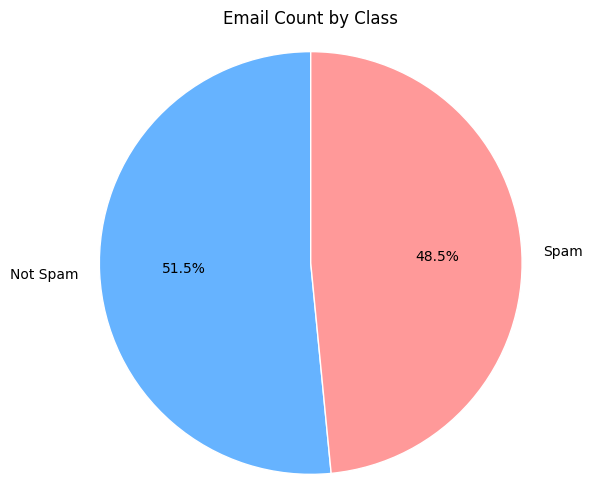

In [7]:
# 3.1 Class Distribution

print_section("Label Check")
counts = df["spam"].value_counts()

percent = df["spam"].value_counts(
    normalize=True
) * 100

print("Counts:")
print(counts)

print("\nPercentages:")
for label, p in percent.items():
    print(f"Class {label}: {p:.2f}%")


# Visualize: Pie chart Email Count by Class
counts = df["spam"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=["Not Spam", "Spam"],
    autopct="%.1f%%",
    startangle=90,
    colors=["#66b3ff", "#ff9999"],
    wedgeprops={"edgecolor": "white"}
)

plt.title("Email Count by Class")
plt.axis("equal")
plt.show()

## 3.2. Email Length Analysis

Độ dài email được phân tích để khám phá đặc điểm của tập dữ liệu và sự khác biệt giữa các nhóm email.

Các phân tích được thực hiện:

- Thống kê mô tả.
- So sánh độ dài giữa Spam và Non-Spam.
- Histogram phân bố.
- Boxplot phát hiện ngoại lệ.
- Skewness.
- Phát hiện Outlier bằng IQR và Z-Score.

In [8]:
# Feature Engineering: tạo cột mới "email_length" tính độ dài của email
df["email_length"] = df["text"].str.len()
df[["text", "email_length"]].head()

,text,email_length
0,Subject: naturally irresistible your corporate...,1484
1,Subject: the stock trading gunslinger fanny i...,598
2,Subject: unbelievable new homes made easy im ...,448
3,Subject: 4 color printing special request add...,500
4,"Subject: do not have money , get software cds ...",235


### 3.2.1 Descriptive Statistics

Mục tiêu:

- Xác định xu hướng trung tâm của dữ liệu.
- Đánh giá mức độ phân tán của độ dài email.
- Quan sát giá trị nhỏ nhất và lớn nhất.

In [9]:
# Statistics on email length
print_section("Email Length Statistics")
print(df["email_length"].describe())


                       Email Length Statistics                        
count     8395.000000
mean      1483.073853
std       2018.258844
min          7.000000
25%        442.000000
50%        871.000000
75%       1799.000000
max      43952.000000
Name: email_length, dtype: float64


### 3.2.2 Group Statistic

Mục tiêu:

- So sánh đặc điểm độ dài email giữa hai lớp Spam và Non-Spam.
- Xác định liệu độ dài email có thể là một đặc trưng phân biệt hữu ích hay không.

In [10]:
# Group Statistic: riêng cho từng class spam/ham

print_section("Mean Email Length By Class")

print(
    df.groupby("spam")["email_length"]
      .describe()
)


                      Mean Email Length By Class                      
       count         mean          std   min    25%     50%      75%      max
spam                                                                         
0     4327.0  1634.200139  1965.016383  13.0  577.5  1122.0  2037.50  43952.0
1     4068.0  1322.325713  2061.506744   7.0  347.0   649.5  1382.25  28432.0


## 3.3 Histogram Analysis

Mục tiêu:

- Quan sát hình dạng phân phối của độ dài email.
- Kiểm tra mức độ tập trung dữ liệu.
- Xác định sự tồn tại của các giá trị cực lớn.

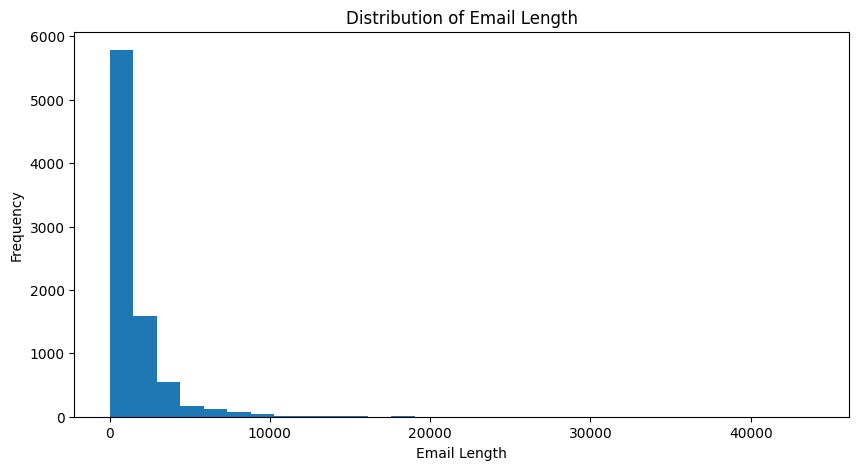

In [11]:
# Histogram: thể hiện phân bố độ dài email cho cả dataset

plt.figure(figsize=(10, 5))

plt.hist(df["email_length"], bins=30)

plt.title("Distribution of Email Length")
plt.xlabel("Email Length")
plt.ylabel("Frequency")

plt.show()

## 3.4 Skewness Analysis

Mục tiêu: Đánh giá mức độ lệch của phân phối.

Nguyên tắc:

- Skewness ≈ 0: phân phối đối xứng.
- Skewness > 0: lệch phải.
- Skewness < 0: lệch trái.

In [12]:
# Skewness: đo độ lệch của phân bố email length

print(
    "Skewness:",
    df["email_length"].skew()
)

Skewness: 5.990675247853012


## 3.5 Boxplot Analysis

Mục tiêu:

- So sánh phân bố độ dài email giữa các lớp.
- Phát hiện các giá trị ngoại lệ trực quan.

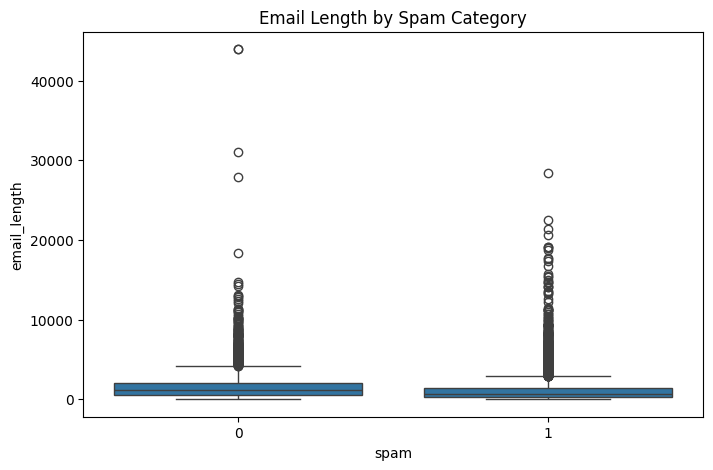

In [13]:
# Boxplot: so sánh phân bố độ dài email giữa spam và not spam

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="spam",
    y="email_length",
    data=df
)

plt.title(
    "Email Length by Spam Category"
)

plt.show()

## 3.6 Outlier Detection

Kiểm tra các email có độ dài bất thường bằng:

- IQR Method
- Z-Score Method

Việc phát hiện ngoại lệ giúp hiểu rõ hơn về cấu trúc dữ liệu.

### 3.6.1 IQR Method

Mục tiêu:

* Phát hiện ngoại lệ dựa trên khoảng tứ phân vị.
* Phù hợp với dữ liệu không tuân theo phân phối chuẩn.

In [14]:
Q1 = df["email_length"].quantile(0.25)

Q3 = df["email_length"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["email_length"] < lower_bound)
    |
    (df["email_length"] > upper_bound)
]

print("IQR Outliers:", len(outliers))

print("IQR Outliers Data:")
outliers[["text", "email_length"]].head(5)

IQR Outliers: 594
IQR Outliers Data:


,text,email_length
6,Subject: here ' s a hot play in motion homela...,9340
13,Subject: wall street phenomenon reaps rewards ...,8196
42,Subject: hidden gems help get a leg up on the ...,9352
49,"Subject: breaking biotech news hey , i though...",18999
51,Subject: grab this quick triple at its low ho...,9345


### 3.6.2 Z-Score Method

Mục tiêu:

* Phát hiện ngoại lệ dựa trên độ lệch chuẩn.
* So sánh với kết quả từ phương pháp IQR.

In [15]:
mean = df["email_length"].mean()

std = df["email_length"].std()

z_scores = (df["email_length"] - mean) / std

outliers_z = (abs(z_scores) > 3).sum()

print("Z-score Outliers:", outliers_z)

Z-score Outliers: 161


---
## [Phase 4: Text Preprocessing]

Email là dữ liệu văn bản thô nên cần được chuẩn hóa trước khi huấn luyện mô hình.

Các bước xử lý:

1. Chuyển về chữ thường.
2. Loại bỏ tiền tố.
3. Loại bỏ "Subject:".
4. Loại bỏ URL.
5. Loại bỏ HTML tags.
6. Loại bỏ ký tự không phải chữ cái.
7. Dọn khoảng trắng thừa.
8. Loại bỏ Stopword.
9. Lemmatization.
10. Giữ từ dài >= 2 ký tự.

Kết quả sẽ tạo ra phiên bản văn bản sạch hơn để trích xuất đặc trưng.

In [16]:
CUSTOM_STOPWORDS = {
    "com",
    "www",
    "net",
    "org"
}

def clean(text):
    # Chuyển toàn bộ thành chữ thường
    text = text.lower()
    # Remove email reply prefixes (tiền tố)
    text = re.sub(
        r'((re|fw|fwd)\s*:)+',
        ' ',
        text
    )
    # remove "subject:"
    text = re.sub(
        r'subject\s*:',
        ' ',
        text
    )
    # Xoá URL
    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' ',
        text
    )
    # Xoá phần http / https còn sót lại
    text = re.sub(
        r'\bhttps?\b',
        ' ',
        text
    )
    # Xóa HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # Xoá mọi thứ KHÔNG phải chữ cái
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    # Dọn khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()

    # Loại stopword tiếng Anh và chuẩn hóa động từ về dạng gốc
    words = text.split()
    words = [
        word
        for word in words
        if word not in ENGLISH_STOP_WORDS
        and word not in CUSTOM_STOPWORDS
        and len(word) > 1
    ]
    words = [lemmatizer.lemmatize(word, pos='v') for word in words]
    text = ' '.join(words)

    return text


df["text"] = df["text"].apply(clean)
df.to_csv("balance_emails_cleaned.csv", index=False)

# Check
print("Blank rows:",
      (df["text"] == "").sum())

print("Duplicate texts:",
      df["text"].duplicated().sum())

Blank rows: 2
Duplicate texts: 203


In [17]:
# remove blank emails after cleaning
df = df[df["text"].str.strip() != ""]

# remove duplicates after cleaning
df = df.drop_duplicates(subset=["text"])

# Check again after clean
print("Blank rows:",
      (df["text"] == "").sum())

print("Duplicate texts:",
      df["text"].duplicated().sum())
df.to_csv("balance_emails_cleaned.csv", index=False)

print("After clean:", len(df))

Blank rows: 0
Duplicate texts: 0
After clean: 8191


---
## [Phase 5. Dataset Preparation]

Train Test Split:

- Training Set
- Testing Set

Dataset Export: Lưu train/test thành file CSV để các model khác sử dụng.

In [18]:
# Train Test Split

X = df["text"]
y = df["spam"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Train samples:", len(X_train_text))
print("Test samples:", len(X_test_text))

Train samples: 6552
Test samples: 1639


In [19]:
# Dataset Export
train_df = pd.DataFrame({
    "text": X_train_text.values,
    "spam": y_train.values
})

test_df = pd.DataFrame({
    "text": X_test_text.values,
    "spam": y_test.values
})

train_df.to_csv("train_balance.csv", index=False)
test_df.to_csv("test_balance.csv", index=False)

---
## [Phase 6: Feature Engineering]
- Vocabulary Analysis
- TF-IDF Feature Extraction

### 6.1 Vocabulary Analysis

Mục tiêu:

Phân tích quy mô từ vựng của tập dữ liệu nhằm đánh giá mức độ đa dạng của nội dung email trước khi thực hiện TF-IDF Vectorization.

Các chỉ số được xem xét:

- Tổng số từ xuất hiện trong tập dữ liệu.
- Tổng số từ duy nhất.
- Mức độ phong phú của từ vựng.

In [20]:
# VOCABULARY ANALYSIS: Count unique words before vectorization
all_words = " ".join(
    df["text"]
).split()

unique_words = set(
    all_words
)

print("Total words:", len(all_words))

print("Unique words:", len(unique_words))

Total words: 1008331
Unique words: 60093


### 6.2 TF-IDF Feature Extraction

In [21]:
# VECTORIZATION: Chuyển text → số

vectorizer = TfidfVectorizer(
    token_pattern=r'\b\w{2,}\b',
    sublinear_tf=True,
    min_df=5,
    max_df=0.95,
    ngram_range=(1, 2),
    max_features=10000
)

X_train = vectorizer.fit_transform(X_train_text)

X_test = vectorizer.transform(X_test_text)

# in shape
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Lưu vectorizer
joblib.dump(
    vectorizer,
    "tfidf_vectorizer_balance.pkl"
)
print("Vectorizer saved!")

# lưu feature count để debug
print(
    "Vocabulary size:",
    len(vectorizer.vocabulary_)
)

# lưu data sau khi vectorize
joblib.dump(X_train, "X_train_balance.pkl")
joblib.dump(X_test, "X_test_balance.pkl")

joblib.dump(y_train, "y_train_balance.pkl")
joblib.dump(y_test, "y_test_balance.pkl")

Train shape: (6552, 10000)
Test shape: (1639, 10000)
Vectorizer saved!
Vocabulary size: 10000


['y_test_balance.pkl']

In [22]:
# Lấy tên các feature
feature_names = vectorizer.get_feature_names_out()

# Tách Spam và Ham
spam_idx = np.array(y_train == 1)

ham_idx = np.array(y_train == 0)

# Mean TF-IDF của từng feature theo từng lớp
spam_scores = np.asarray(
    X_train[spam_idx].mean(axis=0)
).ravel()
ham_scores = np.asarray(
    X_train[ham_idx].mean(axis=0)
).ravel()

# Top 10 Spam terms
spam_top = (
    pd.DataFrame({
        "term": feature_names,
        "score": spam_scores
    })
    .sort_values("score", ascending=False)
    .head(10)
)

# Top 10 Ham terms
ham_top = (
    pd.DataFrame({
        "term": feature_names,
        "score": ham_scores
    })
    .sort_values("score", ascending=False)
    .head(10)
)

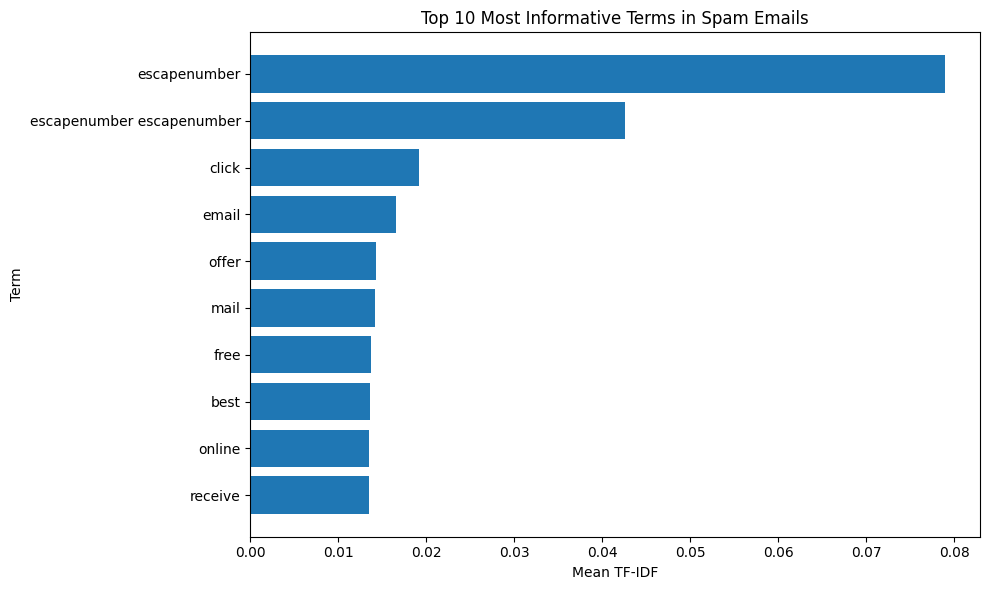

In [23]:
# Biểu đồ: Những token nào mang nhiều thông tin nhất trong lớp Spam?

plt.figure(figsize=(10, 6))

plt.barh(
    spam_top["term"][::-1],
    spam_top["score"][::-1]
)

plt.xlabel("Mean TF-IDF")
plt.ylabel("Term")
plt.title("Top 10 Most Informative Terms in Spam Emails")

plt.tight_layout()
plt.show()

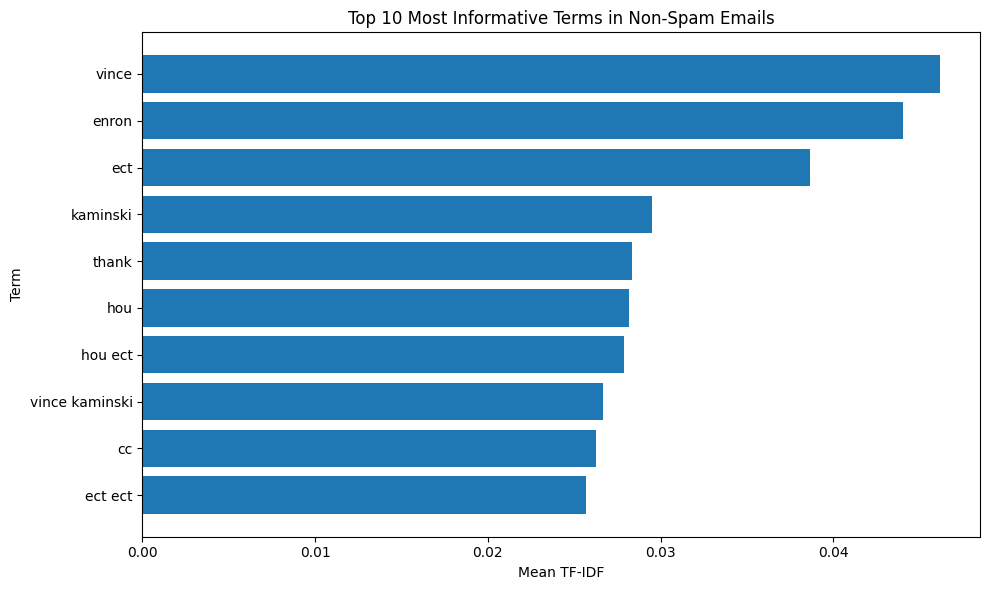

In [24]:
# Biểu đồ: Những token nào mang nhiều thông tin nhất trong lớp Non-Spam?
plt.figure(figsize=(10, 6))

plt.barh(
    ham_top["term"][::-1],
    ham_top["score"][::-1]
)

plt.xlabel("Mean TF-IDF")
plt.ylabel("Term")
plt.title("Top 10 Most Informative Terms in Non-Spam Emails")

plt.tight_layout()
plt.show()

# Conclusion

Các bước đã hoàn thành:

- Data Understanding
- Data Quality Assessment
- Exploratory Data Analysis
- Text Preprocessing
- Dataset Preparation
- Feature Engineering (Vocabulary Analysis + TF-IDF Vectorization)

Dữ liệu đã được cân bằng giữa hai lớp Spam và Non-Spam và hiện đã sẵn sàng để xây dựng và đánh giá các mô hình phân loại Spam Email.